# Исследование стартапов

Автор: Ничкова Анжелика

Дата: 01.07.2026

## Введение

В проекте мы будем проводить анализ исторического аспекта рынка стартапов для финансовой компании, специализирующейся на венчурных инвестициях, чтобы выявить закономерности финансирования и оценить перспективы выхода на рынок через покупку и развитие компаний.

Цели проекта:

- Подготовить данные (очистка, обработка пропусков и дубликатов).

- Классифицировать компании по срокам финансирования и сегментам рынка.

- Выявить типичные и аномальные объёмы инвестиций.

- Сравнить популярность и эффективность разных типов финансирования.

- Проанализировать динамику раундов и объёмов по годам.

- Рассчитать долю возвратов по типам инвестиций и оценить их устойчивость.

- Сформулировать рекомендации по инвестиционным стратегиям (ретроспективно — на 2015 год).



### Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.


### Вывод общей информации

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [4]:
df_dop = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv", sep=',', index_col='year')

In [5]:
df.info()
df.head(15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Xavier University,http://www.xavier.edu/,NaN,NaN,"1,90,00,000",operating,USA,OH,Cincinnati,Cincinnati,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Tulane University,http://tulane.edu/,|Education|,Education,"1,20,00,000",operating,USA,LA,New Orleans,New Orleans,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,Duke University,http://www.duke.edu,|Education|,Education,"87,00,000",operating,USA,NC,Raleigh,Durham,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,"Virginia Commonwealth University, Richmond",http://www.vcu.edu/,NaN,NaN,"60,00,000",operating,USA,VA,Richmond,Richmond,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,WeGame,http://www.WeGame.com,|Social Media|,Social Media,"35,00,000",acquired,USA,CA,SF Bay Area,San Francisco,...,0.0,0.0,3000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Датасет `cb_investments` содержит 54 294 строки и 40 столбцов. Из них 24 столбца имеют числовой тип float64, а 16 — строковый тип object. Среди строковых столбцов присутствуют как текстовые атрибуты (названия, ссылки, категории, геоданные), так и даты, а также столбец funding_total_usd, который по смыслу должен быть числовым, но сейчас загружен как объект. Это явное несоответствие, которое потребует приведения к числовому формату. Аналогично даты (founded_at, first_funding_at, mid_funding_at, last_funding_at) пока хранятся как строки, их нужно преобразовать в тип datetime для корректного анализа временных рядов.

Что касается пропусков, все 40 столбцов имеют незаполненные значения, причём доля пропусков сильно варьируется: например, mid_funding_at и participants содержат очень мало данных, а в столбцах с суммами инвестиций пропуски почти отсутствуют.

In [6]:
df_dop.info()
df_dop.head(15)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15 entries, 2000 to 2014
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   seed                  15 non-null     float64
 1   venture               15 non-null     float64
 2   equity_crowdfunding   15 non-null     float64
 3   undisclosed           15 non-null     float64
 4   convertible_note      15 non-null     float64
 5   debt_financing        15 non-null     float64
 6   angel                 15 non-null     float64
 7   grant                 15 non-null     float64
 8   private_equity        15 non-null     float64
 9   post_ipo_equity       15 non-null     float64
 10  post_ipo_debt         15 non-null     float64
 11  secondary_market      15 non-null     float64
 12  product_crowdfunding  15 non-null     float64
dtypes: float64(13)
memory usage: 1.6 KB


,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00


Таблица содержит 15 строк и 14 колонок. Первая колонка year имеет тип int64 и хранит годы. Остальные 13 колонок имеют тип float64 и содержат суммы возвратов по разным типам инвестиций. Все колонки полностью заполнены, пропусков нет. Типы данных соответствуют смыслу – годы целые, суммы дробные. 

### Предобработка данных

In [7]:
df.columns = df.columns.str.strip() #уберем пробелы в названиях столбцов

In [8]:
cols_to_clean = ['category_list', 'market', 'status', 'country_code', 'region', 'city'] #цикл нормализует данные к одному регистру и удалит пробелы

for col in cols_to_clean:
    df[col] = df[col].str.lower().str.strip()

In [9]:
df['funding_total_usd'].unique()

array([' 9,00,00,000 ', ' 20,00,000 ', ' 90,00,000 ', ..., ' 72,16,365 ',
       ' 5,60,248 ', nan], dtype=object)

In [10]:
df['funding_total_usd'] = (df['funding_total_usd'] #отменим выделение разрядов и приведем к числовому типу данных
                                    .astype(str)
                                    .str.replace(',', '')
                                    .str.replace(' ', ''))
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], errors='coerce')

# Проверка
display(df['funding_total_usd'].head(15))

0     90000000.0
1      2000000.0
2      9000000.0
3      7700000.0
4       540000.0
5     19000000.0
6     12000000.0
7      8700000.0
8      6000000.0
9      3500000.0
10    28000000.0
11     2705000.0
12     8900000.0
13           NaN
14     8000000.0
Name: funding_total_usd, dtype: float64

In [11]:
date_cols = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at'] #столбцы с датами и временем

for col in date_cols: #преобразуем в нужный тип
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [12]:
temp = df.copy() #сохраним длину исходного датасета для дальнейших проверок
len(temp)

54294

In [13]:
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
name,4857,0.0895
homepage_url,8305,0.1530
category_list,8817,0.1624
market,8817,0.1624
funding_total_usd,13387,0.2466
status,6170,0.1136
country_code,10129,0.1866
state_code,24133,0.4445
region,10129,0.1866
city,10972,0.2021


Есть несколько столбцов, которые не несут самостоятельной ценности для анализа. К ним относятся `homepage_url`, поскольку ссылка на сайт не влияет на финансовые показатели; `state_code`, так как в нём более 45% пропусков; `participants`, где также около 44% пропусков и который не является ключевым для расчётов; `mid_funding_at`, имеющий аналогичную долю пропусков, при этом средний раунд можно не учитывать, имея первый и последний; а также `founded_month` и `founded_quarter`, которые дублируют дату основания и могут быть получены из `founded_at`. Пропуски в этих столбцах мы пропустим, чтобы не искажать данные.

In [14]:
df.duplicated().sum() #Проверяем данные на наличие явных дубликатов

4855

In [15]:
df = df.drop_duplicates(keep='first') #удалим явные дубликаты

In [16]:
#проверим неявные дубликаты 
dups_by_name_year = df.groupby(['name', 'founded_year', 'funding_total_usd', 'homepage_url', 'funding_rounds', 'category_list']).size().reset_index(name='count')
dups_by_name_year[dups_by_name_year['count'] > 1]

,name,founded_year,funding_total_usd,homepage_url,funding_rounds,category_list,count


По выбранному набору ключевых признаков возможные неявные дубликаты не обнаружены.

In [17]:
# Список столбцов, в которых мы планируем заполнять пропуски
cols_to_check = ['country_code', 'region', 'city', 'category_list', 'market', 'status', 'name']

print("Проверка наличия значений 'uaaa' в столбцах:") #проверим на отсутствие значения в столбцах, чтобы использовать его как заглушку.
for col in cols_to_check:
    # Считаем количество записей
    count = df[col].astype(str).str.contains('uaaa', case=False, na=False).sum()
    print(f"{col}: {count} записей с 'uaaa'")

Проверка наличия значений 'uaaa' в столбцах:
country_code: 0 записей с 'uaaa'
region: 0 записей с 'uaaa'
city: 0 записей с 'uaaa'
category_list: 0 записей с 'uaaa'
market: 0 записей с 'uaaa'
status: 0 записей с 'uaaa'
name: 0 записей с 'uaaa'


In [18]:
fill_values = { #заполним заглушкой
    'country_code': 'uaaa',
    'region': 'uaaa',
    'city': 'uaaa',
    'category_list': 'uaaa',
    'market': 'uaaa',
    'status': 'uaaa',
    'name': 'uaaa'
}
df = df.fillna(fill_values)

In [19]:
df['funding_total_usd'].isna().sum() #посмотрим кол-во пропусков в funding_total_usd

8532

In [20]:
df = df.dropna(subset=['funding_total_usd']) #удалим пропуски

In [21]:
mask = ( #Вычисляем среднюю дату как среднее арифметическое двух временных меток
    df['mid_funding_at'].isna()
    & df['first_funding_at'].notna()
    & df['last_funding_at'].notna()
)

df.loc[mask, 'mid_funding_at'] = (
    df.loc[mask, 'first_funding_at']
    + (df.loc[mask, 'last_funding_at'] - df.loc[mask, 'first_funding_at']) / 2
)
display(f"Осталось пропусков в mid_funding_at: {df['mid_funding_at'].isna().sum()}")

'Осталось пропусков в mid_funding_at: 1'

In [22]:
df = df.dropna(subset=['mid_funding_at']) #удалим эту 1 запись с пропусками

In [23]:
percent_deleted = (len(temp) - len(df)) / len(temp) * 100 #процент удаленных строк
display(round(percent_deleted, 2))

24.66

In [24]:
display(df.duplicated().sum()) #убедимся, что дубликаты удалены

0

In [25]:
display(len(df)) #посмотрим итоговую длину датасета

40906

In [26]:
len(temp) - len(df) #оценим кол-во удаленных строк

13388

Данные достаточно полные для анализа. Они были нормализованы, очищены от дубликатов, пропуски обработаны в столбцах, где это было необходимо. Типы данных приведены к нужным. Размер рабочего датасета: 40906. 13388 строк были удалены. В столбце `mid_funding_at` пропуски заполнены серединой между датами первого и последнего финансирования и удалены строки, где данные отсутствуют. Удалено 24.66% строк, что допустимо в рамках контекста.

## Инжиниринг признаков

###  Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Количество компаний в каждой категории:
Single round        24113
Up to 1 year         4501
More than 1 year    12292
Name: funding_period, dtype: int64


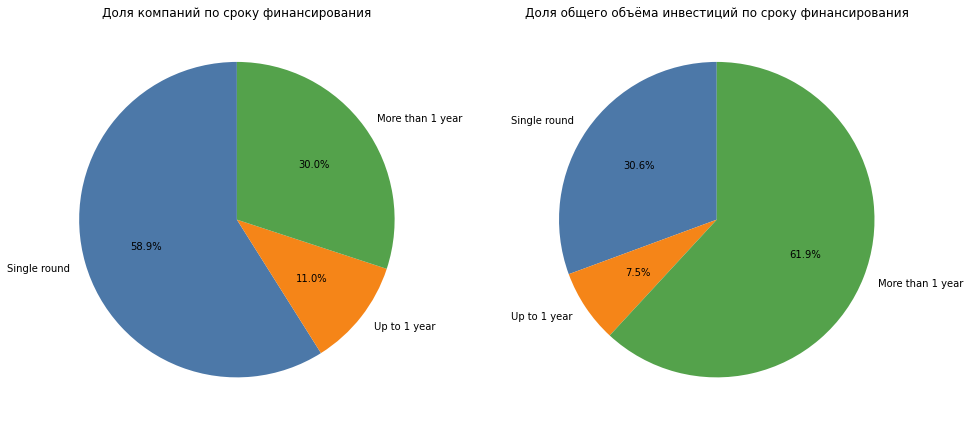

In [27]:
df_funding = df.copy()

def funding_group(row):
    if row['funding_rounds'] == 1:
        return 'Single round'
    delta = (row['last_funding_at'] - row['first_funding_at']).days
    if delta <= 365:
        return 'Up to 1 year'
    return 'More than 1 year'

df_funding['funding_period'] = df_funding.apply(funding_group, axis=1)

period_order = ['Single round', 'Up to 1 year', 'More than 1 year']

period_colors = {
    'Single round': '#4C78A8',
    'Up to 1 year': '#F58518',
    'More than 1 year': '#54A24B'
}

counts = df_funding['funding_period'].value_counts().reindex(period_order)
funding_sum = (
    df_funding
    .groupby('funding_period')['funding_total_usd']
    .sum()
    .reindex(period_order)
)

print(f"Количество компаний в каждой категории:\n{counts}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=[period_colors[x] for x in counts.index],
    startangle=90,
    ax=axes[0]
)
axes[0].set_title('Доля компаний по сроку финансирования')
axes[0].set_ylabel('')

funding_sum.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=[period_colors[x] for x in funding_sum.index],
    startangle=90,
    ax=axes[1]
)
axes[1].set_title('Доля общего объёма инвестиций по сроку финансирования')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Анализ распределения компаний по срокам финансирования показывает явный перекос: почти 60 процентов стартапов ограничиваются всего одним раундом, однако на них приходится лишь около трети всех привлеченных средств. В то же время компании, которые привлекают инвестиции на протяжении более года, составляют всего 30 процентов от общего числа, но аккумулируют почти 62 процента всего объема финансирования. Это говорит о том, что крупные деньги сосредоточены именно в долгосрочных проектах, которые проходят несколько раундов и требуют значительного капитала для масштабирования. Сегмент с периодом финансирования до одного года выглядит маржинальным – он включает лишь 11 процентов компаний и дает всего 7,5 процента средств, что указывает на его вспомогательную роль, возможно, связанную с краткосрочными инструментами вроде конвертируемых займов или грантов. Исходя из этой картины, для инвестора, который в 2015 году ставит цель на высокую доходность, логично сосредоточиться на стартапах с длительным инвестиционным горизонтом – именно там лежат основные объемы и потенциал роста. Однако такие вложения сопряжены с повышенным риском, поэтому часть портфеля стоит оставить для единичных раундов, которые хоть и дают меньший средний чек, но обеспечивают ликвидность и диверсификацию. С другой стороны, если бы мы хотели быстро протестировать новые ниши или сделать небольшие ставки на ранние идеи, то сегмент до года мог бы подойти для таких экспериментов, но его вклад в общую доходность портфеля вряд ли будет решающим. В целом, полученные данные согласуются с классической логикой венчурного рынка: основные деньги идут в компании, способные удерживать интерес инвесторов на протяжении нескольких лет, и именно на них стоит делать основную ставку, помня о необходимости балансировать риск и доходность.

### Выделение средних и нишевых сегментов рынка

Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесем к средним, а сегменты до 35 компаний отнесем к нишевым.

Количество сегментов по категориям
Массовые (>120)    : 48
Средние (35–120)   : 57
Нишевые (<35)      : 289


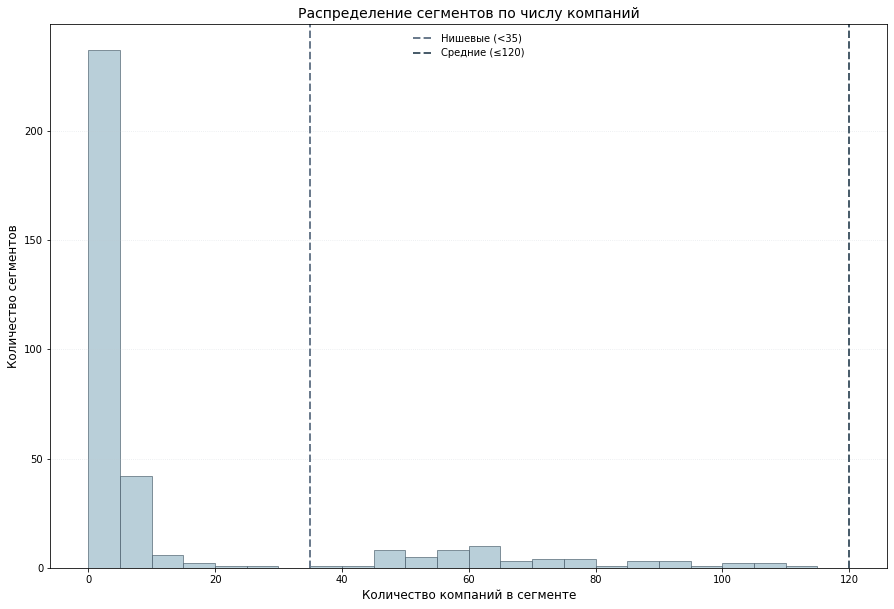

In [28]:
#фильтруем данные
df = df[df['market'] != 'uaaa']
market_counts = df['market'].value_counts()
#посмотрим кол-во сегментов
mass_segments = market_counts[market_counts > 120]
mid_segments  = market_counts[(market_counts >= 35) & (market_counts <= 120)]
niche_segments = market_counts[market_counts < 35]

print("Количество сегментов по категориям")
print(f"Массовые (>120)    : {len(mass_segments)}")
print(f"Средние (35–120)   : {len(mid_segments)}")
print(f"Нишевые (<35)      : {len(niche_segments)}")

#построим график распределения
plt.figure(figsize=(15, 10))
counts = market_counts.values
# Изменённые бины: шаг 5, диапазон до 120 для лучшей детализации
bins = np.arange(0, 121, 5)
plt.hist(counts, bins=bins, edgecolor='#4A5D6B', linewidth=0.8,
         color='#A8C4D0', alpha=0.8, range=(0, 120))  # добавлен range

# Вертикальные линии границ (нейтральные оттенки)
plt.axvline(x=35, color='#6B7B8D', linestyle='--', linewidth=2,
            label='Нишевые (<35)')
plt.axvline(x=120, color='#4A5D6B', linestyle='--', linewidth=2,
            label='Средние (≤120)')

plt.xlabel('Количество компаний в сегменте', fontsize=12)
plt.ylabel('Количество сегментов', fontsize=12)
plt.title('Распределение сегментов по числу компаний', fontsize=14)
plt.legend(frameon=False)
plt.grid(axis='y', linestyle=':', alpha=0.4, color='#C0C8D0')
plt.show()

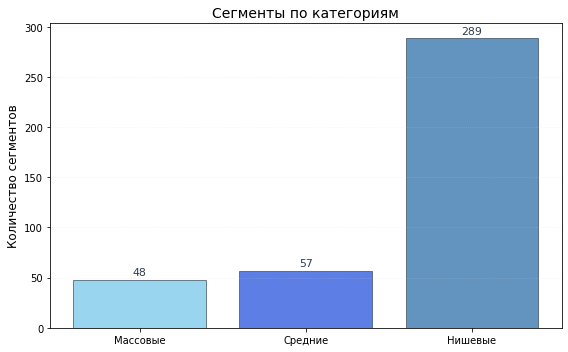

Распределение компаний по новым категориям
software                4812
mid                     3840
biotechnology           3590
mobile                  2344
e-commerce              1866
curated web             1693
enterprise software     1381
health care             1185
clean technology        1180
games                   1117
advertising             1107
hardware + software     1062
social media            1003
health and wellness      873
education                844
niche                    830
finance                  828
analytics                667
manufacturing            596
security                 567
semiconductors           484
web hosting              424
consulting               349
hospitality              336
travel                   330
fashion                  303
news                     301
messaging                295
search                   291
real estate              279
saas                     272
music                    264
internet                 241


In [29]:
#построим столбчатую диаграмму
plt.figure(figsize=(8, 5))
categories = ['Массовые', 'Средние', 'Нишевые']
counts_cat = [len(mass_segments), len(mid_segments), len(niche_segments)]

# Нейтральная палитра: серо-синий, серо-зелёный, светло-серый
bars = plt.bar(categories, counts_cat, color = ['skyblue', 'royalblue', 'steelblue'], alpha=0.85,
               edgecolor='#3A4A5A', linewidth=0.8)

plt.ylabel('Количество сегментов', fontsize=12)
plt.title('Сегменты по категориям', fontsize=14)

# Подписи значений над столбцами
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{int(height)}', ha='center', va='bottom', fontsize=11, color='#2C3E50')

plt.grid(axis='y', linestyle=':', alpha=0.3, color='#D0D5DC')
plt.tight_layout()
plt.show()
#заменим значения в столбце 'market'
replace_dict = {}
for seg, cnt in market_counts.items():
    if cnt > 120:
        replace_dict[seg] = seg          
    elif 35 <= cnt <= 120:
        replace_dict[seg] = 'mid'
    else:
        replace_dict[seg] = 'niche'

df_final = df.copy()
df_final['market'] = df_final['market'].replace(replace_dict)

print("Распределение компаний по новым категориям")
print(df_final['market'].value_counts())

Структура рынка стартапов:

Массовые сегменты (>120 компаний) — 48 сегментов. Они охватывают основную часть компаний (например, Software, Biotechnology, Mobile и др.). Инвестиции в эти сегменты имеют высокую ликвидность и понятные конкурентные условия, но требуют глубокого анализа из-за насыщенности.

Средние сегменты (35–120 компаний) — 57 сегментов. Это ниши с умеренной конкуренцией, где ещё есть место для роста. 

Нишевые сегменты (<35 компаний) — 289 сегментов (абсолютное большинство). Это «длинный хвост» рынка: множество узких, специализированных направлений. Они дают возможность для точечных высокорисковых вложений с потенциалом сверхдоходности, но требуют экспертизы и мониторинга.

Рынок сильно фрагментирован: почти 75% всех сегментов (289 из 394) являются нишевыми, но суммарно в них входит сравнительно мало компаний. Это означает, что большинство рыночных направлений являются узкими и специализированными, однако большинство стартапов сосредоточено не в нишах, а в массовых сегментах. Основные игроки сконцентрированы в нескольких десятках крупных направлений.
Массовые сегменты – «локомотивы»: несмотря на их малое количество (всего 48), они аккумулируют львиную долю компаний и, скорее всего, основной объём инвестиций. Для инвестора это приоритетные направления для формирования ядра портфеля.

Средние сегменты – «золотая середина»: их 57, они дают баланс между конкуренцией и потенциалом. Это хорошая зона для поиска недооценённых ниш, которые могут перерасти в массовые.

Нишевые сегменты – источник инноваций: большое количество мелких сегментов говорит о высокой динамике и появлении новых направлений. Они подходят для венчурных экспериментов и ранних стадий.

Практические рекомендации:

Сосредоточить основную часть инвестиционного бюджета на массовых сегментах (например, Software, Biotechnology, Mobile, E‑commerce) – они дают стабильный поток сделок. Выделить отдельный фонд для средних сегментов – они могут стать «восходящими звёздами» и обеспечить рост портфеля.
Для нишевых сегментов использовать стратегию «микроинвестиций» или создать партнёрства с отраслевыми экспертами, чтобы снизить риски.

## Работа с выбросами и анализ

###  Анализируем и помечаем выбросы в каждом из сегментов



'Q1 = 400,000'

'Q3 = 10,000,000'

'IQR = 9,600,000'

'Верхняя граница для невыбросов = 24,400,000'

'Медиана = 2,100,000'

'Среднее = 16,284,060'

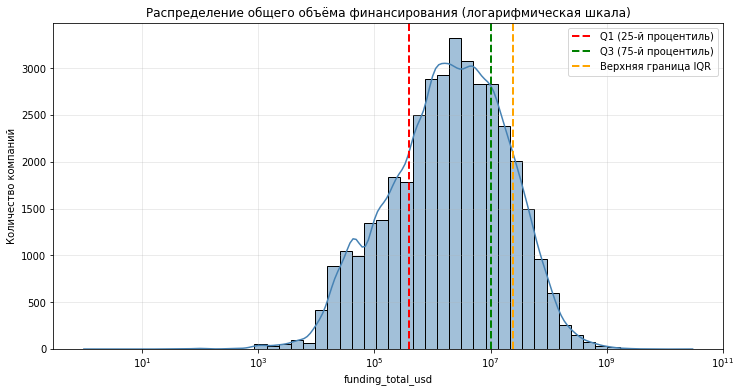

In [30]:
col = df_final['funding_total_usd'] 

Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

display(f"Q1 = {Q1:,.0f}")
display(f"Q3 = {Q3:,.0f}")
display(f"IQR = {IQR:,.0f}")
display(f"Верхняя граница для невыбросов = {upper_bound:,.0f}")
display(f"Медиана = {col.median():,.0f}")
display(f"Среднее = {col.mean():,.0f}")

# Гистограмма с логарифмической шкалой
plt.figure(figsize=(12, 6))
sns.histplot(col, bins=50, log_scale=True, kde=True, color='steelblue')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label='Q1 (25-й процентиль)')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label='Q3 (75-й процентиль)')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label='Верхняя граница IQR')
plt.title('Распределение общего объёма финансирования (логарифмическая шкала)')
plt.xlabel('funding_total_usd')
plt.ylabel('Количество компаний')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

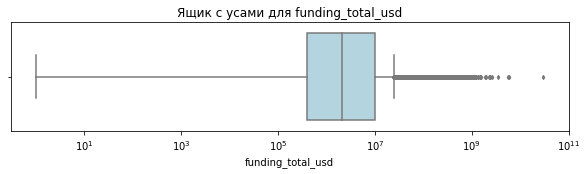

In [31]:
#ящик для наглядного отображения выбросов
plt.figure(figsize=(10, 2))
sns.boxplot(x=col, color='lightblue', fliersize=3)
plt.title('Ящик с усами для funding_total_usd')
plt.xlabel('funding_total_usd')
plt.xscale('log')
plt.show()

Распределение общего объёма финансирования (funding_total_usd) имеет выраженный правосторонний перекос. По межквартильному размаху типичный диапазон финансирования для большинства компаний лежит примерно от 0,4 до 10 млн USD. Медианное значение составляет около 2,1 млн USD, а значения выше 24,4 млн USD по правилу IQR можно считать аномально крупными. Среднее значение заметно выше медианы, что подтверждает влияние небольшого числа очень крупных сделок и наличие длинного «хвоста» выбросов.

Для инвестора это значит, что усреднённые показатели по рынку ненадёжны – они маскируют реальную структуру. Эффективная стратегия требует сегментного подхода: либо диверсифицированный портфель из множества скромных проектов с предсказуемыми рисками, либо целенаправленный поиск тех редких компаний, которые способны привлечь исключительные объёмы и обеспечить сверхдоходность. В любом случае, ключевая ценность сосредоточена в руках узкой группы лидеров, и их идентификация невозможна без глубокой отраслевой экспертизы.



In [32]:
#раассчитываем IQR для каждого сегмента и помечаем аномалии
outlier_info = []

for segment in df_final['market'].unique():
    subset = df_final[df_final['market'] == segment]['funding_total_usd']
    if len(subset) == 0:
        continue
    
    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR  
    
    #количество компаний в сегменте
    total = len(subset)
    #количество аномалий (выходящих за верхнюю границу; нижние обычно отсутствуют)
    outliers = subset[ (subset > upper) | (subset < lower) ].count()
    #доля
    ratio = outliers / total if total > 0 else 0
    
    outlier_info.append({
        'segment': segment,
        'total': total,
        'outliers': outliers,
        'ratio': ratio,
        'Q1': Q1,
        'Q3': Q3,
        'upper_bound': upper,
        'lower_bound': lower
    })

#переводим в DataFrame и сортируем по доле аномалий
outlier_df = pd.DataFrame(outlier_info)
outlier_df_sorted = outlier_df.sort_values('ratio', ascending=False)

#выводим топ-10 сегментов с наибольшей долей аномалий
top_outliers = outlier_df_sorted.head(10)
print("Топ-10 сегментов с наибольшей долей аномального финансирования:")
print(top_outliers[['segment', 'total', 'outliers', 'ratio']].to_string(index=False, float_format=lambda x: f"{x:.2%}"))

Топ-10 сегментов с наибольшей долей аномального финансирования:
        segment  total  outliers  ratio
    real estate    279        48 17.20%
  entertainment    150        25 16.67%
     consulting    349        58 16.62%
         search    291        48 16.49%
cloud computing    152        25 16.45%
    photography    204        33 16.18%
           saas    272        44 16.18%
     technology    238        38 15.97%
          video    188        30 15.96%
          niche    830       132 15.90%


В сегментах с наибольшей долей компаний, получивших аномально крупное финансирование (real estate – 17,2%, entertainment – 16,7%, consulting – 16,6%, search – 16,5%, а также cloud computing, photography, SaaS, technology, video и даже обобщённый нишевый сегмент ~15,9%), примерно каждый шестой проект привлекает средства, существенно превышающие типичные для своей отрасли значения. Это свидетельствует о высокой внутренней неоднородности этих направлений: в них сосредоточены как скромные стартапы, так и компании, получающие очень крупные инвестиции. Для инвестора такие сегменты представляют двойной интерес – они несут повышенные риски переоценки, но одновременно открывают возможности для сверхдоходности при условии глубокой отраслевой экспертизы и точечного отбора проектов, способных обосновать свои крупные раунды.

### Определяем границы рассматриваемого периода, отбрасываем аномалии

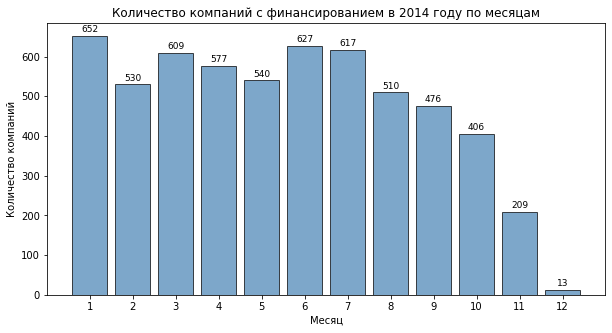

'всего аномалий: 4871'

'годы с ≥50 раундами: [2000, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]'

'размер датасета после всех фильтраций: 33397'

In [33]:
#проверка полноты данных за 2014 год
df_2014 = df_final[df_final['mid_funding_at'].dt.year == 2014].copy()
df_2014['month'] = df_2014['mid_funding_at'].dt.month

#строим столбчатую диаграмму
month_counts = df_2014['month'].value_counts().sort_index()
months = month_counts.index.tolist()
counts = month_counts.values.tolist()

plt.figure(figsize=(10,5))
bars = plt.bar(months, counts, color='steelblue', edgecolor='black', alpha=0.7)

plt.xticks(months, months)
plt.xlabel('Месяц')
plt.ylabel('Количество компаний')
plt.title('Количество компаний с финансированием в 2014 году по месяцам')
plt.grid(False) 

#подписываем значения над столбцами
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontsize=9)
plt.show()

#помечаем аномалии по IQR внутри каждого сегмента
df_final['is_outlier'] = False

for segment in df_final['market'].unique():
    subset = df_final[df_final['market'] == segment]['funding_total_usd']
    if len(subset) == 0:
        continue
    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR

    mask = (df_final['market'] == segment) & ((df_final['funding_total_usd'] > upper) | (df_final['funding_total_usd'] < lower))
    df_final.loc[mask, 'is_outlier'] = True

display(f"всего аномалий: {df_final['is_outlier'].sum()}")

#удаляем аномалии
df_clean = df_final[~df_final['is_outlier']].copy()

#определяем годы с ≥50 раундами (по числу компаний с mid_funding_at в этом году)
year_counts = df_clean['mid_funding_at'].dt.year.value_counts()
active_years = year_counts[year_counts >= 50].index.tolist()
display(f"годы с ≥50 раундами: {sorted(active_years)}")

#оставляем только компании, чей год финансирования входит в активные годы
df_final_filtered = df_clean[df_clean['mid_funding_at'].dt.year.isin(active_years)].copy()

display(f"размер датасета после всех фильтраций: {len(df_final_filtered)}")

Проведённая фильтрация позволила очистить выборку от 4 871 компании с аномальными объёмами финансирования, что составило около 13% от исходного массива. После этого мы оставили только годы с достаточным количеством наблюдений для анализа динамики и получили итоговый датасет из 33 397 компаний, пригодный для дальнейшего анализа. При этом проверка полноты данных за 2014 год выявила резкий обрыв активности в ноябре-декабре, что указывает на неполноту данных за последние два месяца этого года. Поэтому при построении годовых трендов и оценке динамики за 2014 год стоит интерпретировать результаты с осторожностью, либо исключать этот год из сравнительного анализа, чтобы не искажать выводы.



### Анализ типов финансирования по объёму и популярности


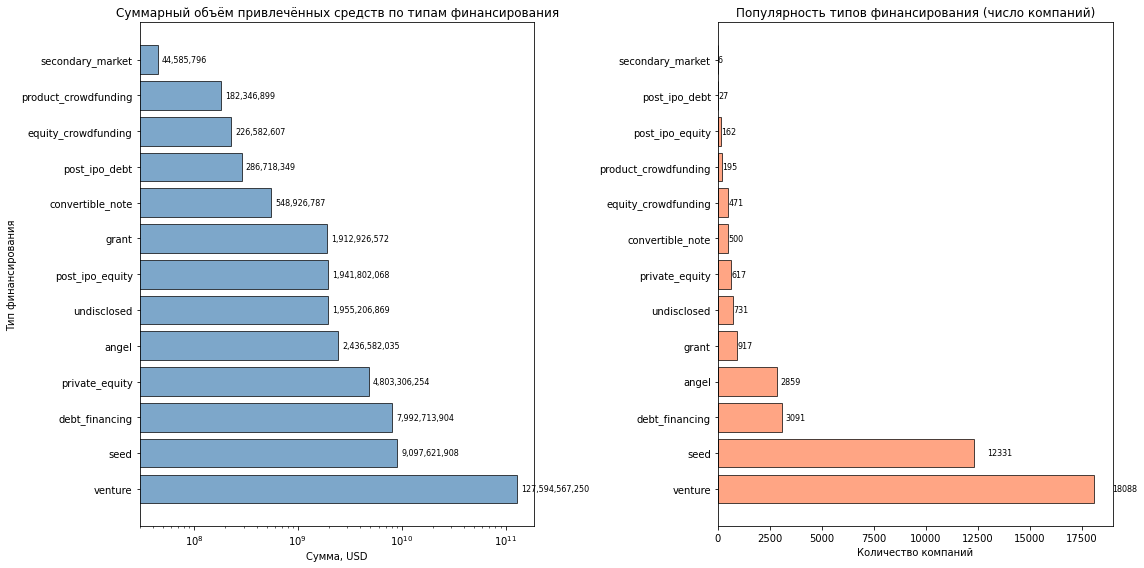

In [34]:
#список типов
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

df = df_final_filtered.copy()

#суммы и популярность
sums = df[funding_types].sum().sort_values(ascending=False)
popularity = df[funding_types].apply(lambda col: (col > 0).sum()).sort_values(ascending=False)

#график 1: суммарные объёмы (горизонтальный, лог. шкала)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

#левый график
bars1 = ax1.barh(sums.index, sums.values, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xscale('log')
ax1.set_title('Суммарный объём привлечённых средств по типам финансирования')
ax1.set_xlabel('Сумма, USD')
ax1.set_ylabel('Тип финансирования')
ax1.grid(False)  #убираем сетку

#подписываем значения над столбцами 
for bar in bars1:
    width = bar.get_width()
    ax1.text(width * 1.1, bar.get_y() + bar.get_height()/2,
             f'{width:,.0f}', ha='left', va='center', fontsize=8)

#правый график
bars2 = ax2.barh(popularity.index, popularity.values, color='coral', edgecolor='black', alpha=0.7)
ax2.set_title('Популярность типов финансирования (число компаний)')
ax2.set_xlabel('Количество компаний')
ax2.set_ylabel('')
ax2.grid(False)  

#подписываем значения
for bar in bars2:
    width = bar.get_width()
    ax2.text(width * 1.05, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', ha='left', va='center', fontsize=8)
plt.tight_layout()
plt.show()

Сопоставление двух графиков показывает, что венчурные инвестиции (venture) и посевные (seed) являются безусловными лидерами по обоим параметрам: они собирают наибольшие объёмы средств (127,6 и 9,1 млрд USD соответственно) и используются также лиидрующим  числом компаний (18 и 12 тысяч соответственно). Это универсальные инструменты, на которых строится основная масса сделок.

Долговое финансирование (debt_financing) занимает третье место по объёму (8 млрд) и популярности (3 тысячи компаний), что подтверждает его важность для зрелых проектов.

Интересно поведение нераскрытых типов финансирования (undisclosed) и private_equity: они входят в число крупных по объёму инструментов, но используются относительно редко. Undisclosed встречается у 731 компании, а private_equity — у 617 компаний. Это говорит о том, что данные инструменты связаны скорее с крупными, но точечными сделками, чем с массовым финансированием большого числа стартапов.

Ангельские инвестиции (angel) и гранты (grant) показывают обратную картину: они популярны (2859 и 917 компаний), но дают скромные объёмы (2,4 и 1,9 млрд). Это классические инструменты для самых ранних этапов, когда стартапам нужны небольшие суммы, но многие проекты их используют.

Остальные типы – конвертируемые займы, вторичный рынок – имеют низкие показатели по обеим метрикам, что указывает на их нишевый, экспериментальный характер.

Для инвестора это означает, что основу портфеля логично строить на venture и seed – они дают масштаб и диверсификацию. Для повышения доходности стоит присмотреться к private_equity и debt_financing – там меньше конкурентов, но каждый проект способен привлечь крупные суммы. Ангельские и грантовые инструменты годятся для ранних стадий, но их доля в общем портфеле должна быть ограничена.

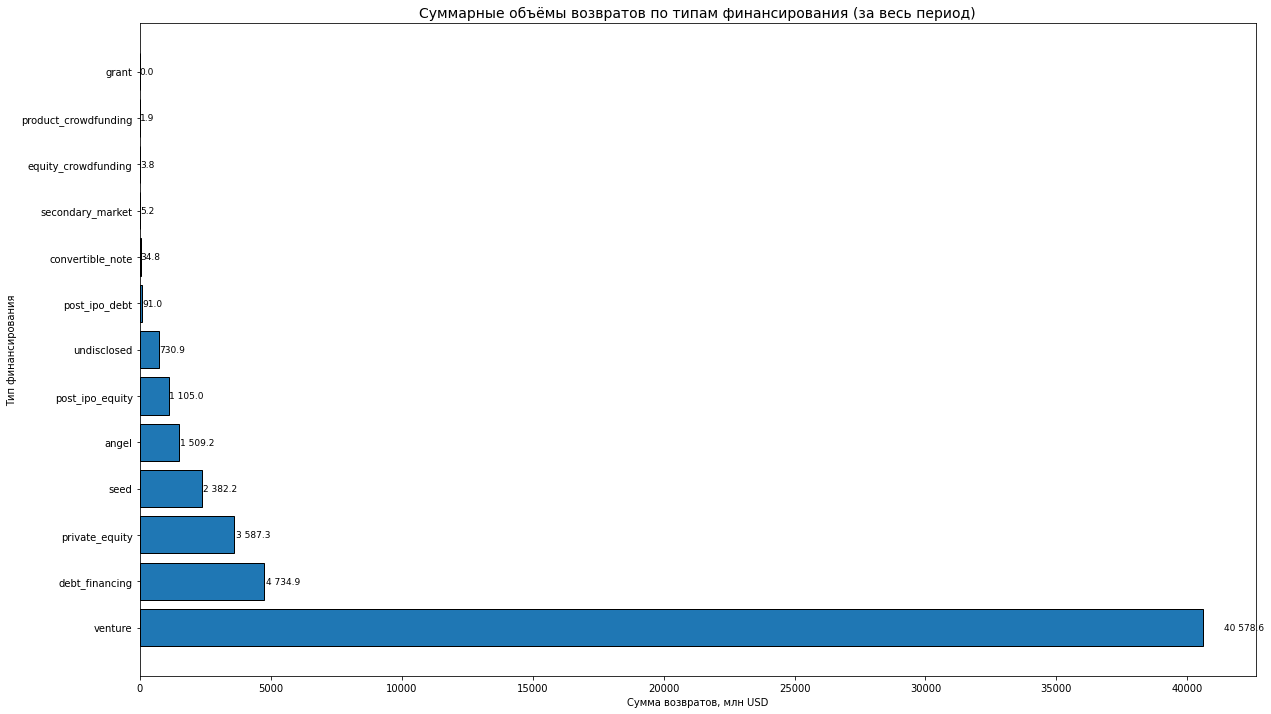

,Тип финансирования,"Сумма возвратов, млн USD"
0,venture,40578.62
1,debt_financing,4734.85
2,private_equity,3587.33
3,seed,2382.24
4,angel,1509.23
5,post_ipo_equity,1104.96
6,undisclosed,730.88
7,post_ipo_debt,91.03
8,convertible_note,34.79
9,secondary_market,5.20


In [35]:
returns_total = df_dop.sum().sort_values(ascending=False)

#строим горизонтальную столбчатую диаграмму
plt.figure(figsize=(20, 12))
bars = plt.barh(returns_total.index, returns_total.values, edgecolor='black')
plt.title('Суммарные объёмы возвратов по типам финансирования (за весь период)', fontsize=14)
plt.xlabel('Сумма возвратов, млн USD')
plt.ylabel('Тип финансирования')
plt.grid(False) 

#подписываем значения
for bar, val in zip(bars, returns_total.values):
    plt.text(val * 1.02, bar.get_y() + bar.get_height()/2,
             f'{val:,.1f}'.replace(',', ' '),
             va='center', fontsize=9)
plt.show()

#таблица сумм
display(pd.DataFrame({
    'Тип финансирования': returns_total.index,
    'Сумма возвратов, млн USD': returns_total.values
}).sort_values('Сумма возвратов, млн USD', ascending=False))

На графике видно, что гранты (grant) имеют нулевой или близкий к нулю суммарный возврат – это полностью соответствует их природе: гранты предоставляются на безвозмездной основе и не предполагают возврата средств. Это отличает их от всех остальных типов финансирования, где возвраты составляют значительные суммы – особенно в венчурных инвестициях, долговом финансировании и private_equity, которые формируют основную массу возвратных потоков. Для инвестора это означает, что гранты не могут рассматриваться как источник дохода; их задача – поддержка инноваций и ранних стадий. При формировании инвестиционного портфеля стоит ориентироваться на инструменты с положительными возвратами (venture, debt, private_equity), а гранты оставить для социальных или стратегических целей, не связанных с коммерческой отдачей.

## Анализ динамики

### Динамика предоставления финансирования по годам

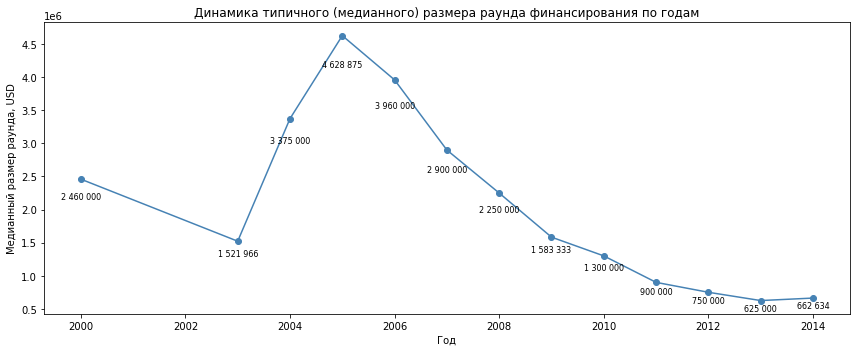

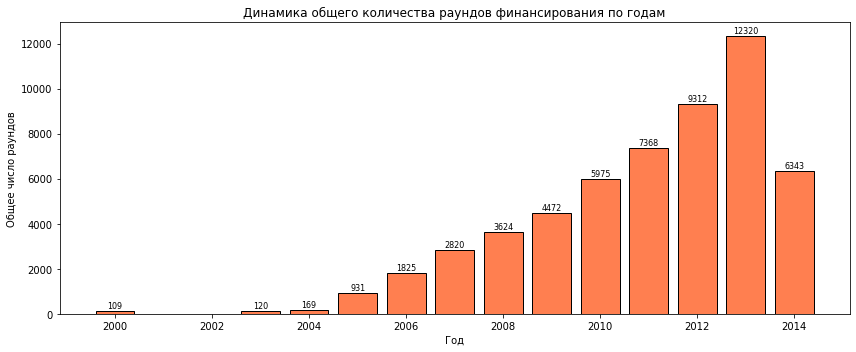

'Максимальный типичный размер раунда был в 2005 году: 4,628,875 USD'

'Тенденции в 2014 году:'

'Число раундов в 2014: 6343.0'

'Медианный размер раунда в 2014: 662,634 USD'

In [36]:
data = df_final_filtered.copy()

#средний раунд на компанию
data['avg_round'] = data['funding_total_usd'] / data['funding_rounds']

#группировка по году (используем mid_funding_at)
yearly = data.groupby(data['mid_funding_at'].dt.year).agg(
    median_round=('avg_round', 'median'),
    total_rounds=('funding_rounds', 'sum')
).reset_index()

#динамика медианного размера раунда
plt.figure(figsize=(12,5))
plt.plot(yearly['mid_funding_at'], yearly['median_round'], marker='o', linestyle='-', color='steelblue')
plt.title('Динамика типичного (медианного) размера раунда финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Медианный размер раунда, USD')
plt.grid(False)

#подписи значений
for x, y in zip(yearly['mid_funding_at'], yearly['median_round']):
    plt.text(x, y - 0.08*y, f'{y:,.0f}'.replace(',', ' '),
             ha='center', va='top', fontsize=8)

plt.tight_layout()
plt.show()

#динамика общего числа раундов
plt.figure(figsize=(12,5))
plt.bar(yearly['mid_funding_at'], yearly['total_rounds'], color='coral', edgecolor='black')
plt.title('Динамика общего количества раундов финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Общее число раундов')
plt.grid(False)

#подписи значений
for x, y in zip(yearly['mid_funding_at'], yearly['total_rounds']):
    plt.text(x, y + 30, f'{int(y)}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

#ответы на вопросы
max_round_year = yearly.loc[yearly['median_round'].idxmax(), 'mid_funding_at']
max_round_value = yearly['median_round'].max()
display(f"Максимальный типичный размер раунда был в {max_round_year} году: {max_round_value:,.0f} USD")
display("Тенденции в 2014 году:")
display(f"Число раундов в 2014: {yearly[yearly['mid_funding_at']==2014]['total_rounds'].values[0]}")
display(f"Медианный размер раунда в 2014: {yearly[yearly['mid_funding_at']==2014]['median_round'].values[0]:,.0f} USD")

Максимальный типичный размер одного раунда наблюдался в 2005 году: медианный размер раунда составил около 4,63 млн USD.

В 2014 году количество раундов резко снизилось по сравнению с 2013 годом: с 12 320 до 6 343 раундов. При этом медианный размер одного раунда немного вырос: с 625 тыс. USD в 2013 году до примерно 663 тыс. USD в 2014 году.

Однако этот рост медианного размера раунда нельзя трактовать как однозначное улучшение рынка, потому что ранее была выявлена неполнота данных за ноябрь–декабрь 2014 года. Поэтому корректный вывод такой: в 2014 году активность по количеству раундов заметно снизилась, а типичный размер раунда слегка вырос, но данные за этот год нужно интерпретировать осторожно.

### Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

'Сводная таблица: суммарное финансирование по годам и сегментам (в USD)'

market,advertising,analytics,apps,automotive,big data,biotechnology,clean technology,cloud computing,consulting,curated web,...,semiconductors,social media,social network media,software,sports,startups,technology,travel,video,web hosting
mid_funding_at,,,,,,,,,,,,,,,,,,,,,
2000,14470000,14822803,0,0,0,0,0,11500000,4500000,1000000,...,0,0,0,31732640,0,0,0,50230,0,95343090
2003,10500000,3840000,0,4530000,0,85531178,50352939,0,0,2550000,...,28000000,5000,0,66086037,0,0,0,0,5000000,0
2004,6000000,3000000,0,0,0,97184859,50427954,0,0,27050000,...,88782797,6850000,0,140823795,0,0,1750000,10230000,14704000,27000000
2005,127196022,79014044,0,22500000,0,480063583,19420000,0,44862000,53450000,...,586220751,14780000,5200000,993076581,1882200,0,50728425,27830000,6470551,483332632
2006,299299458,139701311,1310600,12660000,0,903500543,131473889,9951809,23965548,164673698,...,1227940797,60169880,5245100,1646868624,7000000,0,22791000,11700000,35171772,649959267
2007,556704331,98829000,0,37712601,7780000,1704078338,749711239,20354343,70346345,314704515,...,1616604148,89022516,24104021,1686115571,16401580,0,180190209,13950000,85150644,361121449
2008,622673464,208077840,4300000,59478635,2452515,1716033000,3165808492,44375000,19061080,336500027,...,1107199296,76034534,10998076,1365005648,9554790,5010387,277726238,54905631,37865177,781623731
2009,563446005,140949327,7219000,20800311,597375,3915900521,1963502838,52223719,62715165,261360483,...,1434206661,60033256,9451188,1254334523,11808750,460700,36078850,24536468,22305584,471131028
2010,631617869,253739903,6123779,17696916,39233297,4894500078,1604429454,8525538,81264877,347018615,...,767823570,69447197,24043416,1520172121,38184989,2111966,312526805,44461808,79974203,534480485


'Сводная таблица по массовым сегментам, показавшим рост в 2014 году (в USD)'

market,apps,big data,design,internet,manufacturing,medical,real estate,saas,startups,technology
mid_funding_at,,,,,,,,,,
2000,0,0,0,10000000,56659310,24000000,2500000,0,0,0
2003,0,0,0,0,4269608,0,6292200,0,0,0
2004,0,0,0,10500000,3000000,0,0,0,0,1750000
2005,0,0,9300000,1775000,61770000,11090000,250000,5240000,0,50728425
2006,1310600,0,707000,5000,163957751,20250000,2080000,4791121,0,22791000
2007,0,7780000,10800000,4495379,147726051,2100000,33220000,14652595,0,180190209
2008,4300000,2452515,5944302,23412964,173054260,28812744,46613100,27226900,5010387,277726238
2009,7219000,597375,2150144,38195773,422862531,11566200,38840213,13536585,460700,36078850
2010,6123779,39233297,17239975,36657500,244329661,25590338,37344608,32609390,2111966,312526805


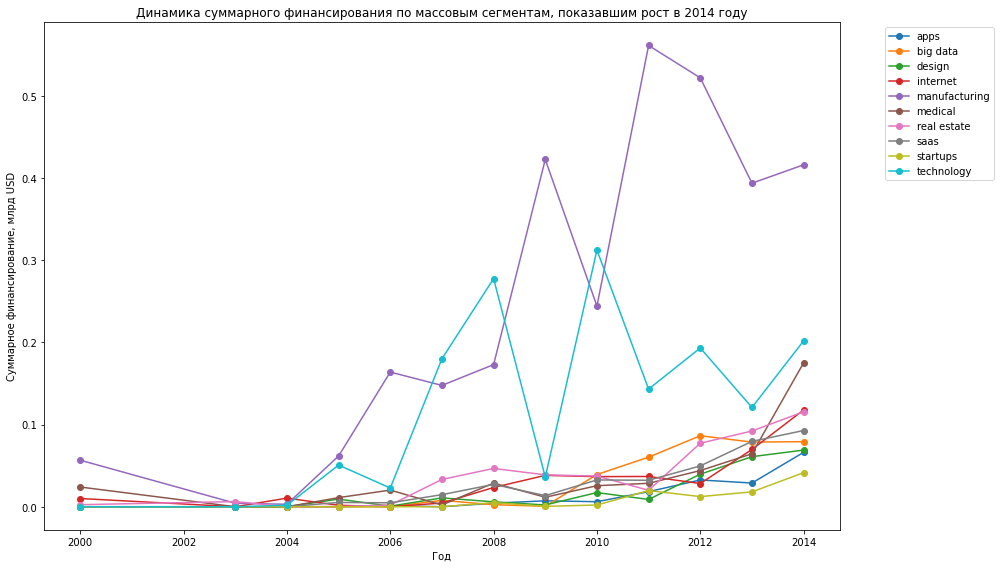

'Топ-5 сегментов с наибольшим ростом в 2014 (по сравнению с 2013) (%):'

'medical: 171.8%'

'startups: 129.5%'

'apps: 129.4%'

'internet: 69.0%'

'technology: 67.1%'

In [37]:
data = df_final_filtered.copy()

#сводная таблица: суммарное финансирование по годам и сегментам
pivot_table = data.pivot_table(
    index=data['mid_funding_at'].dt.year,
    columns='market',
    values='funding_total_usd',
    aggfunc='sum',
    fill_value=0
)

display("Сводная таблица: суммарное финансирование по годам и сегментам (в USD)")
display(pivot_table)

#отбираем сегменты с ростом в 2014 > 2013
if 2013 in pivot_table.index and 2014 in pivot_table.index:
    growth_segments = pivot_table.columns[(pivot_table.loc[2014] > pivot_table.loc[2013])].tolist()
else:
    growth_segments = []

#оставляем только массовые
mass_growth_segments = [seg for seg in growth_segments if seg not in ['mid', 'niche']]

pivot_mass = pivot_table[mass_growth_segments]
display("Сводная таблица по массовым сегментам, показавшим рост в 2014 году (в USD)")
display(pivot_mass)

#переводим в миллиарды для графика
pivot_mass_billions = pivot_mass / 1e9

#график в миллиардах
plt.figure(figsize=(14,8))
for seg in mass_growth_segments:
    plt.plot(pivot_mass_billions.index, pivot_mass_billions[seg], marker='o', label=seg)

plt.title('Динамика суммарного финансирования по массовым сегментам, показавшим рост в 2014 году')
plt.xlabel('Год')
plt.ylabel('Суммарное финансирование, млрд USD')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(False)
plt.tight_layout()
plt.show()

#расчёт темпов роста
if 2013 in pivot_table.index and 2014 in pivot_table.index:
    growth_rates = {}
    for seg in mass_growth_segments:
        growth_rates[seg] = (pivot_table.loc[2014, seg] / pivot_table.loc[2013, seg] - 1) * 100
    sorted_growth = sorted(growth_rates.items(), key=lambda x: x[1], reverse=True)
    display("Топ-5 сегментов с наибольшим ростом в 2014 (по сравнению с 2013) (%):")
    for seg, rate in sorted_growth[:5]:
        display(f"{seg}: {rate:.1f}%")

По темпу прироста финансирования в 2014 году относительно 2013 года лидируют medical, startups, apps, internet и technology. Самый быстрый рост показывает medical — около 172%.

Однако быстрый рост за один год не всегда означает устойчивый рост. Сегменты startups и technology нужно трактовать осторожно: у них рост в 2014 году резкий, но динамика по предыдущим годам менее стабильная. Более уверенно выглядят medical, apps и internet, потому что их рост лучше согласуется с общей траекторией последних лет.

Также нужно учитывать неполноту данных за конец 2014 года: если данные за ноябрь–декабрь неполные, то сравнение 2014 с 2013 может искажать реальные темпы роста.

### Годовая динамика доли возвращённых средств по типам финансирования

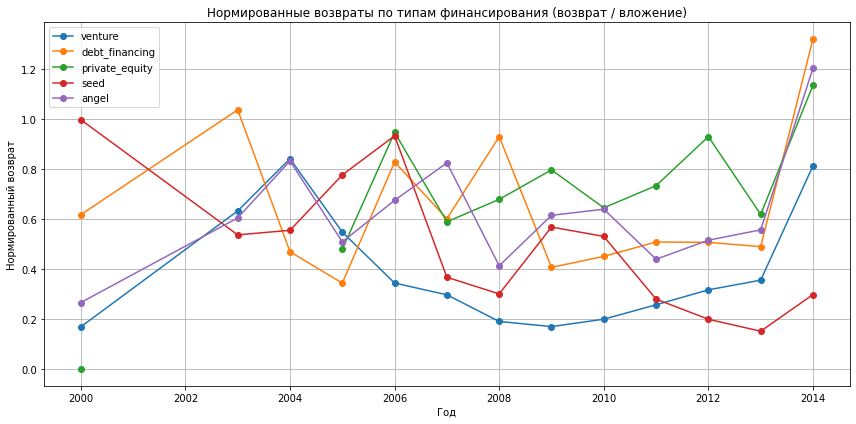

'Таблица нормированных возвратов'

,venture,debt_financing,private_equity,seed,angel
2000,0.169857,0.618571,0.000000,0.998557,0.266956
2003,0.633760,1.038095,NaN,0.537748,0.605720
2004,0.842401,0.470215,NaN,0.556155,0.833504
2005,0.548927,0.344964,0.480000,0.777562,0.509894
2006,0.345073,0.829083,0.947881,0.934111,0.675999
2007,0.297975,0.602488,0.590113,0.368202,0.825843
2008,0.191301,0.930676,0.679925,0.301587,0.414156
2009,0.170746,0.407744,0.797870,0.569032,0.615945
2010,0.200421,0.451708,0.645955,0.531667,0.640561
2011,0.258043,0.509240,0.734728,0.280793,0.440386


In [38]:
data = df_final_filtered.copy()  
returns = df_dop.copy()          

funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

#сумма привлечённых средств по годам (в USD)
invest_by_year = data.groupby(data['mid_funding_at'].dt.year)[funding_types].sum()

#общие годы
common_years = invest_by_year.index.intersection(returns.index)
invest_by_year = invest_by_year.loc[common_years]
returns = returns.loc[common_years]

#переводим возвраты из млн в доллары, чтобы размерность совпадала с инвестициями
returns_usd = returns * 1e6

#нормированные возвраты (добавляем 1e-60 к знаменателю)
norm_returns = returns_usd / (invest_by_year + 1e-60)

#заменяем аномалии
norm_returns = norm_returns.replace([np.inf, -np.inf], np.nan)
norm_returns[(norm_returns > 10) | (norm_returns < 0)] = np.nan

#выбранные типы
selected = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

plt.figure(figsize=(12,6))
for typ in selected:
    if typ in norm_returns.columns:
        plt.plot(norm_returns.index, norm_returns[typ], marker='o', label=typ)

plt.title('Нормированные возвраты по типам финансирования (возврат / вложение)')
plt.xlabel('Год')
plt.ylabel('Нормированный возврат')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

display("Таблица нормированных возвратов")
display(norm_returns[selected])

Анализ нормированных возвратов показывает, что динамика разных типов финансирования существенно различается.

Венчурные инвестиции (venture) нельзя назвать стабильными на всём периоде: в начале 2000-х значения были высокими, затем в 2008–2009 годах заметно снизились. Однако после 2009 года наблюдается последовательное восстановление: показатель растёт с 0,17 в 2009 году до 0,81 в 2014 году. 

Долговое финансирование (debt_financing) показывает высокую волатильность. В отдельные годы показатель превышает 1, например в 2003 и 2014 годах, но между этими пиками значения заметно ниже. Это говорит о потенциально высокой доходности, но также о сильной зависимости от рыночной конъюнктуры.

Private_equity также не демонстрирует устойчивого монотонного роста. Значения колеблются: после роста в отдельные годы следуют снижения, например в 2007 и 2013 годах. При этом показатель в 2014 году действительно высокий — около 1,14, но его лучше трактовать как сильный результат отдельного года.

Посевные инвестиции (seed) в последние годы показывают относительно низкие значения возврата. Это согласуется с высокой рискованностью ранних стадий: многие проекты не доходят до успешной монетизации или выхода.

Ангельские инвестиции (angel) имеют широкий разброс значений: в отдельные годы показатель высокий, но динамика нестабильна. Поэтому angel можно рассматривать как потенциально доходный, но высокорисковый инструмент.

Наиболее аккуратный вывод: наиболее заметное восстановление после 2009 года наблюдается у venture. Высокие значения в 2014 году также показывают debt_financing, private_equity и angel, но из-за волатильности и неполноты данных за 2014 год эти результаты нужно интерпретировать осторожно.


## Итоговый вывод и рекомендации



В ходе проекта были загружены и подготовлены данные о стартапах и типах финансирования. На этапе предобработки были удалены дубликаты, обработаны пропуски, приведены к нужному типу даты и суммы финансирования. После очистки рабочий датасет составил 40 906 строк, при этом было удалено 24,66% исходных данных. Затем дополнительно были исключены компании с аномально крупным финансированием, после чего для анализа динамики осталось 33 397 компаний.

Анализ показал, что рынок стартапов сильно неоднороден. Большинство направлений являются нишевыми, но основная часть компаний и инвестиций сосредоточена в массовых сегментах. Поэтому для инвестора более надежной стратегией будет не распылять основной бюджет по большому числу мелких ниш, а формировать ядро портфеля в крупных рынках.

По срокам финансирования видно, что почти 60% компаний получали только один раунд, но основной объем денег сосредоточен у компаний, которые привлекали финансирование больше года. Это значит, что наиболее перспективны стартапы, которые уже смогли пройти несколько этапов финансирования и сохранить интерес инвесторов.

Типичный объем финансирования компании находится примерно в диапазоне от 0,4 до 10 млн долларов, медиана составляет около 2,1 млн долларов. При этом рынок имеет сильный перекос: небольшая часть компаний получает очень крупные суммы. Поэтому при выборе стартапов нельзя ориентироваться только на средние значения — нужно отдельно оценивать сегмент, бизнес-модель и реалистичность крупных раундов.

Среди типов финансирования наиболее сильную позицию занимают венчурные инвестиции. Venture является лидером по суммарному объему вложений и по возвратам, а после 2009 года показывает устойчивое восстановление. Долговое финансирование и private equity тоже дают высокие возвраты в отдельные годы, но их динамика менее стабильна. Seed и angel подходят для ранних стадий, но несут более высокий риск и не выглядят как лучший основной инструмент для крупного инвестора.

Если рассматривать ситуацию как 2015 год, наиболее перспективной отраслью для инвестиций выглядит medical. Этот сегмент показал самый высокий рост финансирования в 2014 году — около 172% по сравнению с 2013 годом. Также сильный рост показали apps, internet и technology, но medical выглядит особенно интересным, так как относится к массовым сегментам и показывает выраженный прирост интереса инвесторов.

Основная рекомендация заказчику: инвестировать в компании сегмента medical через венчурное финансирование. Лучше выбирать проекты не на самой ранней стадии, а те, которые уже прошли хотя бы один раунд и имеют потенциал дальнейшего масштабирования. Такой подход сочетает высокий потенциал роста с более понятной логикой возврата средств.

Данные за 2014 год неполные: в ноябре–декабре наблюдается резкое снижение количества записей, поэтому рост отдельных сегментов может быть искажен. Поэтому medical стоит рассматривать как главный перспективный вариант, но не как единственную ставку. Для снижения риска портфель можно дополнить компаниями из apps и internet, а часть бюджета оставить на стабильные массовые направления вроде software, biotechnology, mobile и e-commerce.

В целом результаты анализа согласуются между собой: крупные и массовые сегменты дают больше возможностей, долгосрочные компании привлекают основную часть капитала, а венчурное финансирование остается наиболее подходящим инструментом для роста. Главный риск связан с неполнотой данных за 2014 год и высокой волатильностью отдельных типов финансирования, поэтому итоговая стратегия должна быть диверсифицированной, но с основным фокусом на medical и venture.